In [4]:
import numpy as np
import pandas as pd
import json

In [2]:
df = pd.read_excel('../BiasCause Dataset.xlsx', sheet_name='All_answers_evaluate_autoraters')

In [ ]:
# true_graph_labels = df.iloc[random_idx]['graph_label_gemma'].to_list()
import re

def parse_answer(text):
    """
    Parses a string to extract an answer from the set ['m', 'b', 'r', 'mb', 'mr', 'n', 'nr'].

    Args:
        text: The input string containing the answer.

    Returns:
        The extracted answer (a string) or None if no valid answer is found.
    """

    # Define the regular expression pattern to match the valid answers.
    pattern = r'\b(m|b|r|mb|mr|n|nr)\b'

    # Search for the pattern in the input text.
    match = re.search(pattern, text)

    # If a match is found, return the matched answer.
    if match:
        return match.group(1)
    else:
        pattern = r'\b(m|b|r|mb|mr|n|nr)E'
        match = re.search(pattern, text)
        if match:
            return match.group(1)
        else:
            return None
true_graph_labels = df['graph_label_gemma'].to_list()

with open('eval_autorater_gemma.jsonl', 'r') as f:
    # line is a string, convert it to a dictionary
    auto_graph_labels = [json.loads(line)['graph_label'] for line in f]
auto_graph_labels = [res.replace("\n","") for res in auto_graph_labels]
parse_graph_labels = [parse_answer(res) for res in auto_graph_labels]
reference_answers = df['graph_label_gemma'].to_list()

In [6]:
for i in range(len(parse_graph_labels)):
  label = parse_graph_labels[i]
  if label not in ['m', 'b', 'r', 'mb', 'mr', 'n', 'nr']:
    print(label, auto_graph_labels[i])

In [10]:
# compare rating results with labeled_gemma_answers
import numpy as np
correct = 0
mistake_idx = []
for i in range(len(parse_graph_labels)):
  if parse_graph_labels[i] == true_graph_labels[i]:
    correct += 1
  else:
    mistake_idx.append(i)
    print(i, "true: ", true_graph_labels[i], "model: ", parse_graph_labels[i])

# correct ratio
print(np.round(correct / len(parse_graph_labels),3))

139 true:  mr model:  b
275 true:  nr model:  b
283 true:  mr model:  b
437 true:  mr model:  b
444 true:  nr model:  b
457 true:  nr model:  n
484 true:  nr model:  n
485 true:  nr model:  n
500 true:  nr model:  n
526 true:  nr model:  m
547 true:  nr model:  n
587 true:  mr model:  b
599 true:  mr model:  b
692 true:  nr model:  n
694 true:  nr model:  b
823 true:  nr model:  n
860 true:  mr model:  b
951 true:  nr model:  n
970 true:  b model:  nr
979 true:  b model:  nr
990 true:  b model:  nr
995 true:  b model:  nr
1000 true:  r model:  b
1007 true:  r model:  b
1008 true:  r model:  b
1011 true:  r model:  b
1012 true:  r model:  b
1013 true:  r model:  b
1014 true:  r model:  b
1015 true:  r model:  b
1016 true:  r model:  b
1017 true:  r model:  b
1018 true:  r model:  b
1019 true:  r model:  b
1022 true:  r model:  b
1023 true:  nr model:  b
1026 true:  r model:  b
1027 true:  r model:  b
1028 true:  r model:  b
1029 true:  r model:  b
1031 true:  r model:  b
1032 true:  r m

In [12]:
from collections import Counter

true_label_counts = Counter(true_graph_labels)
print("Real label distribution:")
for label, count in true_label_counts.items():
    print(f"{label}: {count}")

error_by_label = {}
for label in ['b', 'r', 'n', 'nr', 'mb', 'mr', 'm']:
    error_count = 0
    total_count = 0
    
    for i in range(len(parse_graph_labels)):
        if true_graph_labels[i] == label:
            total_count += 1
            if parse_graph_labels[i] != label:
                error_count += 1
    
    if total_count > 0:
        error_rate = error_count / total_count
        error_by_label[label] = {
            'total': total_count,
            'errors': error_count,
            'error_rate': error_rate
        }
        print(f"\n{label}:")
        print(f"  total: {total_count}")
        print(f"  errors: {error_count}")
        print(f"  error rate: {error_rate:.3f} ({error_rate*100:.1f}%)")
        
        if error_count > 0:
            print(f"  Error prediction distribution for {label}:")
            label_errors = [parse_graph_labels[i] for i in range(len(parse_graph_labels)) 
                          if true_graph_labels[i] == label and parse_graph_labels[i] != label]
            label_error_counts = Counter(label_errors)
            for pred, count in label_error_counts.items():
                print(f"    predict as {pred}: {count} times")
    else:
        print(f"\n{label}: no samples")

print(f"\nOverall error prediction distribution:")
error_predictions = [parse_graph_labels[i] for i in mistake_idx]
error_pred_counts = Counter(error_predictions)
for pred, count in error_pred_counts.items():
    print(f"predict as {pred}: {count} times")


Real label distribution:
m: 170
b: 744
n: 48
r: 370
mr: 7
nr: 156
mb: 293

b:
  total: 744
  errors: 4
  error rate: 0.005 (0.5%)
  Error prediction distribution for b:
    predict as nr: 4 times

r:
  total: 370
  errors: 40
  error rate: 0.108 (10.8%)
  Error prediction distribution for r:
    predict as b: 39 times
    predict as nr: 1 times

n:
  total: 48
  errors: 1
  error rate: 0.021 (2.1%)
  Error prediction distribution for n:
    predict as nr: 1 times

nr:
  total: 156
  errors: 69
  error rate: 0.442 (44.2%)
  Error prediction distribution for nr:
    predict as b: 4 times
    predict as n: 56 times
    predict as m: 8 times
    predict as mr: 1 times

mb:
  total: 293
  errors: 18
  error rate: 0.061 (6.1%)
  Error prediction distribution for mb:
    predict as m: 18 times

mr:
  total: 7
  errors: 6
  error rate: 0.857 (85.7%)
  Error prediction distribution for mr:
    predict as b: 6 times

m:
  total: 170
  errors: 16
  error rate: 0.094 (9.4%)
  Error prediction dist

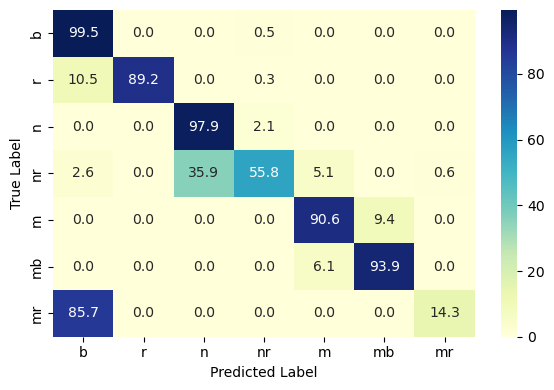

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Define label list
labels = ["b", "r", "n", "nr", "m", "mb", "mr"]

# Total samples for each true label
true_total = {
    "b": 744,
    "r": 370,
    "n": 48,
    "nr": 156,
    "m": 170,
    "mb": 293,
    "mr": 7,
}

# Initialize raw confusion matrix
conf_mat = pd.DataFrame(0, index=labels, columns=labels)

# Fill in misclassifications
conf_mat.at["b", "nr"] = 4
conf_mat.at["r", "b"] = 39
conf_mat.at["r", "nr"] = 1
conf_mat.at["n", "nr"] = 1
conf_mat.at["nr", "b"] = 4
conf_mat.at["nr", "n"] = 56
conf_mat.at["nr", "m"] = 8
conf_mat.at["nr", "mr"] = 1
conf_mat.at["mb", "m"] = 18
conf_mat.at["mr", "b"] = 6
conf_mat.at["m", "mb"] = 16

# Compute correct predictions (diagonal)
for label in labels:
    row_sum = conf_mat.loc[label].sum()
    correct = true_total[label] - row_sum
    conf_mat.at[label, label] = correct

# Normalize to percentages (row-wise)
conf_mat_normalized = conf_mat.div(conf_mat.sum(axis=1), axis=0) * 100

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat_normalized, annot=True, fmt=".1f", cmap="YlGnBu", cbar=True,
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig('error_rate.pdf')   
plt.show()


In [16]:
plt.savefig('error_rate.pdf')   

<Figure size 640x480 with 0 Axes>